# BFD cNF Analysis

End-to-end BFD cNF workflow using the functions defined in the `bfd_cnf` package.
Reproduces all plots from the reference notebook via `viz.py` functions.

## Cell 1 — Environment & Imports

In [1]:
import sys
if '/home/vwetzell/gitrepos' not in sys.path:
    sys.path.insert(0, '/home/vwetzell/gitrepos')

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
%matplotlib inline

# bfd_cnf package imports
from bfd_cnf.config import key, Sigma0, PRIOR_FLOW_PATH, Q_FLOW_PATH, GRID_P_PATH, GRID_M_PATH, prior_sigmax_log_scale_mean
from bfd_cnf.data import load_data, transform_dataset_to_standard, make_augmentation_noise_raw_jax
from bfd_cnf.training import load_or_train, continue_training
from bfd_cnf.inference import (
    make_flow_prob_and_derivs,
    rqmc_integrate_pqr_jax,
    rqmc_pqr_grid,
    load_grid_data,
    assemble_pqr_from_flow,
)
from bfd_cnf.statistics import pqr2g, pqr2multbias, clipR, bootstrap_total_mult_bias
from bfd_cnf.viz import (
    plot_snr_histograms,
    plot_moment_corner,
    plot_resampled_corner,
    plot_flow_vs_obs_corner,
    plot_prob_derivs_m1mr_m2mr,
    plot_prob_derivs_log10mf_mrmf,
    plot_Q_distributions,
    plot_R_distributions,
    plot_g_comparison,
    plot_g_distributions,
    plot_mult_bias_hexbin,
)

## Cell 2 — Data Loading

In [2]:
data = load_data(key=key, subsample=50)
moments_jnp = data["moments_jnp"]
odd_moments_jnp = data["odd_moments_jnp"]
cov_jnp = data["cov_jnp"]
dm_dg_jnp = data["dm_dg_jnp"]
d2m_dg2_jnp = data["d2m_dg2_jnp"]
weights = data["weights"]
resampled = data["resampled"]
data_mean = data["data_mean"]
data_std = data["data_std"]
raw2standard = data["raw2standard"]
x_lo, x_hi = data["x_lo"], data["x_hi"]
y_lo, y_hi = data["y_lo"], data["y_hi"]
key = data["key"]

print(f"Loaded {moments_jnp.shape[0]} templates")
print(
    f"Selection box: log10(Mf) in [{x_lo:.2f}, {x_hi:.2f}], Mr/Mf in [{y_lo:.2f}, {y_hi:.2f}]"
)

Fitted log p(x,y) = -7.140 + -2.103x + 8.573y + -0.137x^2 + -1.498y^2 + 0.320xy
ESS fraction inside box: 0.133
Loaded 239509 templates
Selection box: log10(Mf) in [3.00, 5.70], Mr/Mf in [0.50, 9.00]


## Cell 3 — Plot: SNR Histograms

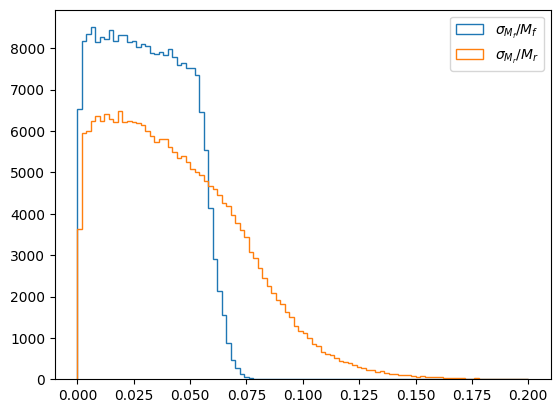

In [3]:
plot_snr_histograms(moments_jnp, cov_jnp)

## Cell 4 — Plot: Moment Corner (raw vs noise-corrected)

## Cell 5 — Plot: Resampled Corner with Selection Box

## Cell 6 — Load / Train Flows

In [4]:
prior_trained, q_trained, losses = load_or_train(
    key,
    moments_jnp,
    odd_moments_jnp,
    cov_jnp,
    dm_dg_jnp,
    d2m_dg2_jnp,
    weights,
    raw2standard,
    prior_path=PRIOR_FLOW_PATH,
    q_path=Q_FLOW_PATH,
)
if losses:
    plt.figure()
    plt.plot(losses)
    plt.xlabel("Step")
    plt.ylabel("ELBO loss")
    plt.title("Training Loss")
    plt.show()
else:
    print("Flows loaded from disk (no training performed).")

Loading models from /home/vwetzell/gitrepos/bfd_cnf/prior_flow_xy.eqx and /home/vwetzell/gitrepos/bfd_cnf/q_flow_xy.eqx
Flows loaded from disk (no training performed).


  0%|          | 0/10000 [00:00<?, ?it/s]E0331 08:37:01.431579  165027 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.636 = f32[128,64,20]{2,1,0} fusion(bitcast.3, bitcast.2), kind=kCustom, calls=gemm_fusion_dot.636_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","32"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0331 08:37:01.431844  165027 xtile_compiler.cc:401] Computation: gemm_fusion_dot.636_computation.clone {
  parameter_0.156 = f32[64,128,288]{0,2,1} parameter(0)
  parameter_1.156 = f32[128,288,20]{2,1,0} parameter(1)
  ROOT dot = f32[128,64,20]{2,1,0} dot(parameter_0.156, parameter_1.156), lhs_batch_dims={1}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs

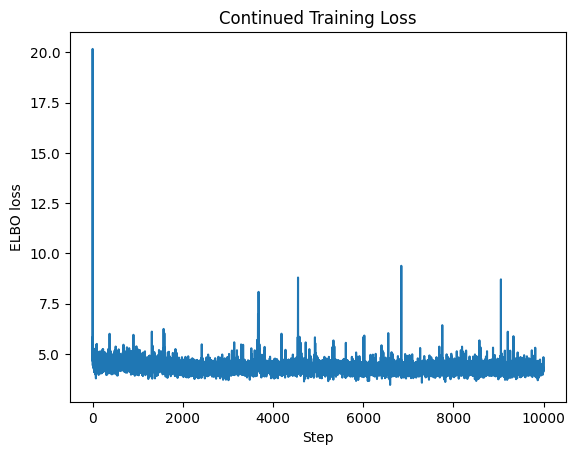

In [5]:
# Continue training if desired

prior_trained, q_trained, new_losses = continue_training(
    key,
    prior_trained,
    q_trained,
    moments_jnp,
    odd_moments_jnp,
    cov_jnp,
    dm_dg_jnp,
    d2m_dg2_jnp,
    weights,
    raw2standard,
    steps=10_000,
    learning_rate=1e-4,
    weight_decay=1e-5,
    grad_clip=0.5,
)
if new_losses:
    plt.figure()
    plt.plot(new_losses)
    plt.xlabel("Step")
    plt.ylabel("ELBO loss")
    plt.title("Continued Training Loss")
    plt.show()
else:
    print("Flows loaded from disk (no continued training performed).")

## Cell 7 — Build Inference Functions

In [6]:
# Reference Σ_X condition: [log_scale, e1, e2] at the prior mean (circular PSF)
sx_cond = jnp.array([prior_sigmax_log_scale_mean, 0.0, 0.0])

flow_prob_and_derivs = make_flow_prob_and_derivs(prior_trained, sx_cond=sx_cond)

def log_flow_fn(x):
    condition = jnp.concatenate([jnp.array([0.0, 0.0]), sx_cond])
    return prior_trained.log_prob(x, condition=condition)

## Cell 8 — Generate Flow Samples + Plot: Flow vs Observed Corner

Samples from the prior flow at `g=(0,0)`, adds measurement noise from `N(0, Σ₀)`,
and compares the resulting noisy distribution to the observed template moments.

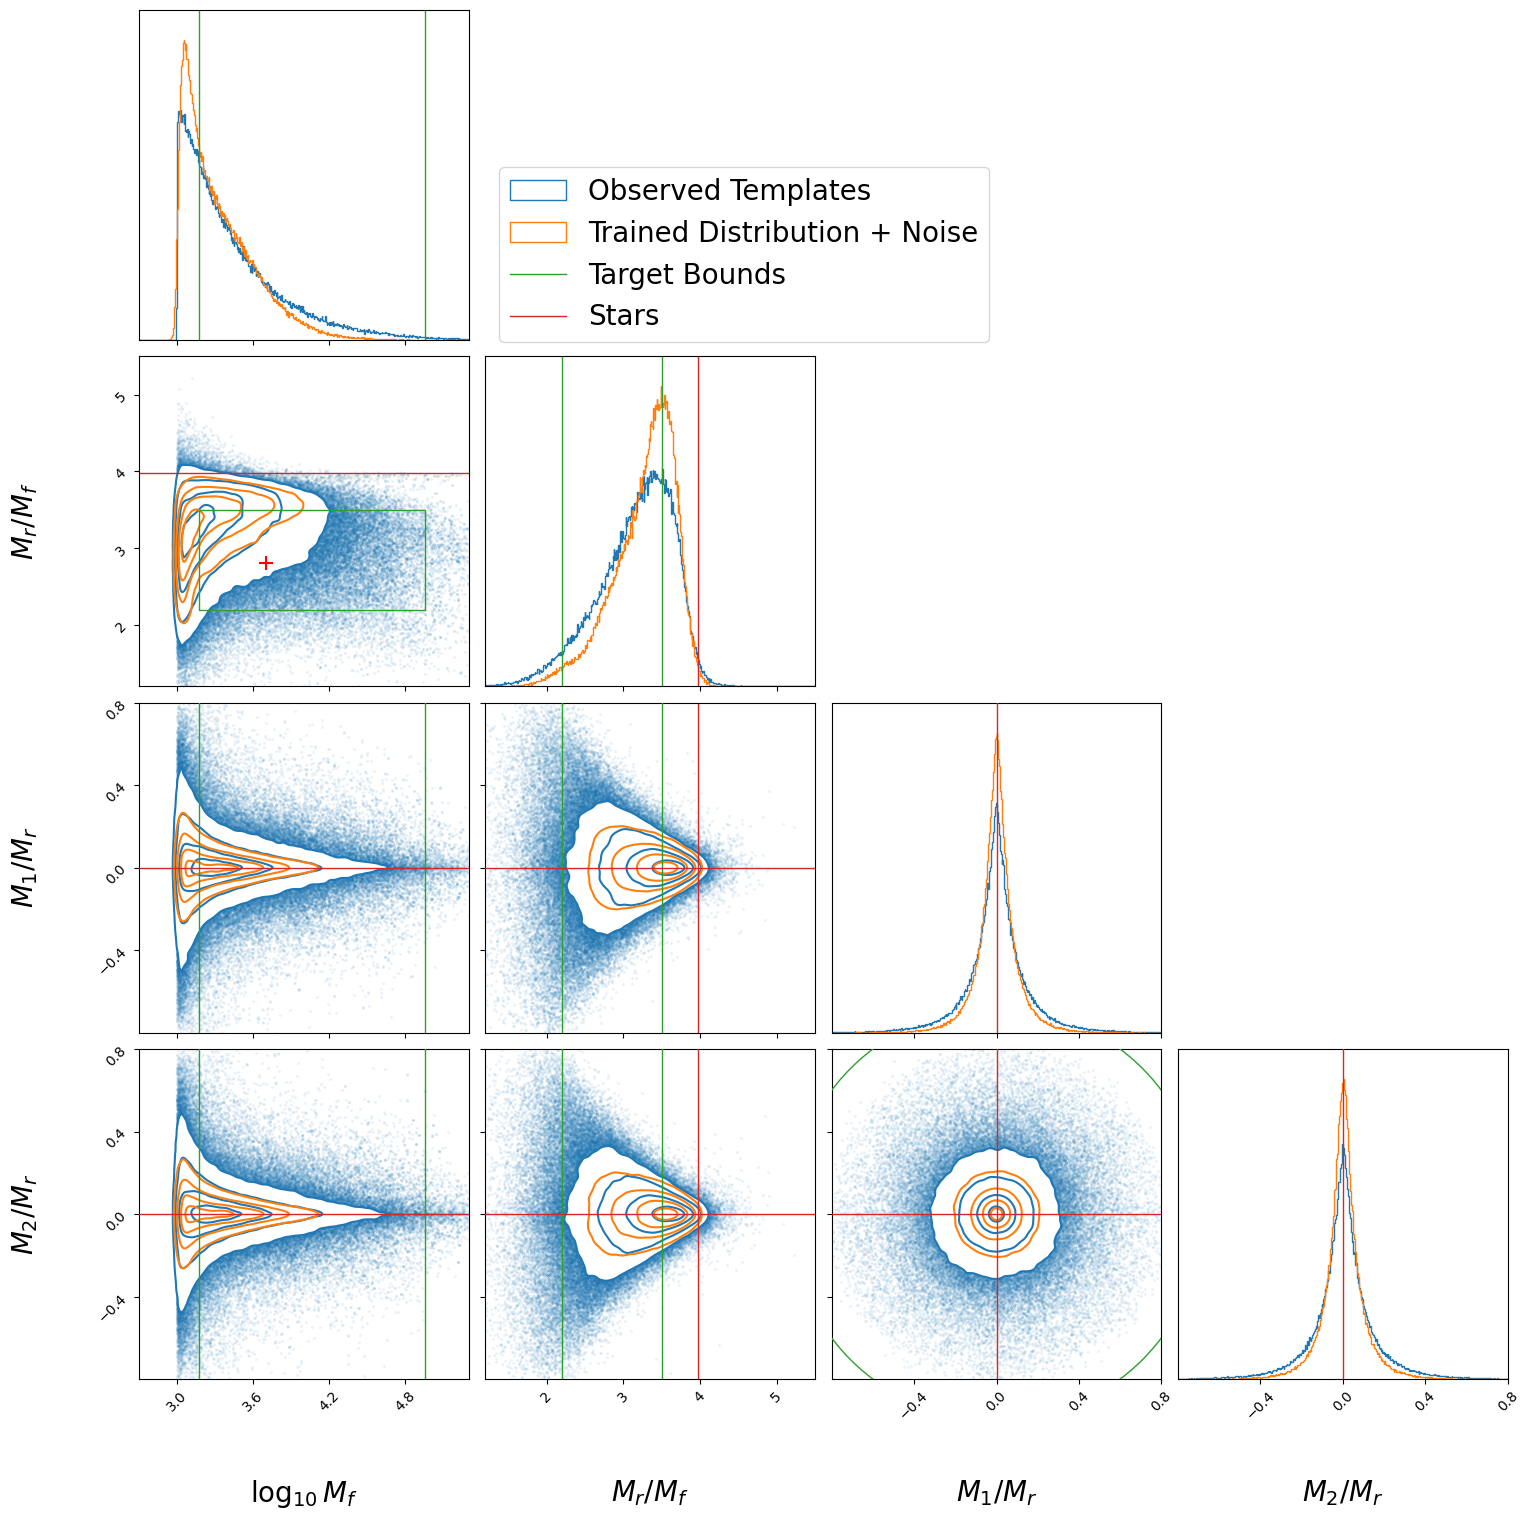

In [7]:
key, subkey = jr.split(key)
N_flow = len(moments_jnp)
std_samples = prior_trained.sample(
    subkey, (N_flow,), condition=jnp.concatenate([jnp.array([0.0, 0.0]), sx_cond])
)

# De-standardize: z-scores → [log10 Mf, Mr/Mf, M1/Mr, M2/Mr]
log_samp = std_samples * data_std + data_mean
Mf_s = 10.0 ** log_samp[:, 0]
Mr_s = log_samp[:, 1] * Mf_s
M1_s = log_samp[:, 2] * Mr_s
M2_s = log_samp[:, 3] * Mr_s
raw_s = jnp.stack([Mf_s, Mr_s, M1_s, M2_s], axis=-1)

# Add measurement noise drawn from N(0, Σ₀)
key, subkey = jr.split(key)
noisy = raw_s 
noisy_v = np.array(noisy)

flow_dist_np_noise = np.column_stack(
    [
        np.log10(noisy_v[:, 0]),
        noisy_v[:, 1] / noisy_v[:, 0],
        noisy_v[:, 2] / noisy_v[:, 1],
        noisy_v[:, 3] / noisy_v[:, 1],
    ]
)

obs_dist_np = np.column_stack(
    [
        np.log10(np.array(moments_jnp[:, 0])),
        np.array(moments_jnp[:, 1] / moments_jnp[:, 0]),
        np.array(moments_jnp[:, 2] / moments_jnp[:, 1]),
        np.array(moments_jnp[:, 3] / moments_jnp[:, 1]),
    ]
)

plot_flow_vs_obs_corner(obs_dist_np, flow_dist_np_noise, data_mean, data_std)

## Cell 9 — Prob Derivatives Grid: M1/Mr vs M2/Mr

Evaluates P and its shear derivatives on a 2D grid in (M1/Mr, M2/Mr) space
at a fixed reference galaxy (log10 Mf ≈ log10(5000), Mr/Mf = 2.8).

`flow_prob_and_derivs` returns derivatives of **log p**; converting:
- `dp/dg = p · d(log p)/dg`
- `d²p/dg² = p · ((d log p/dg)² + d² log p/dg²)`

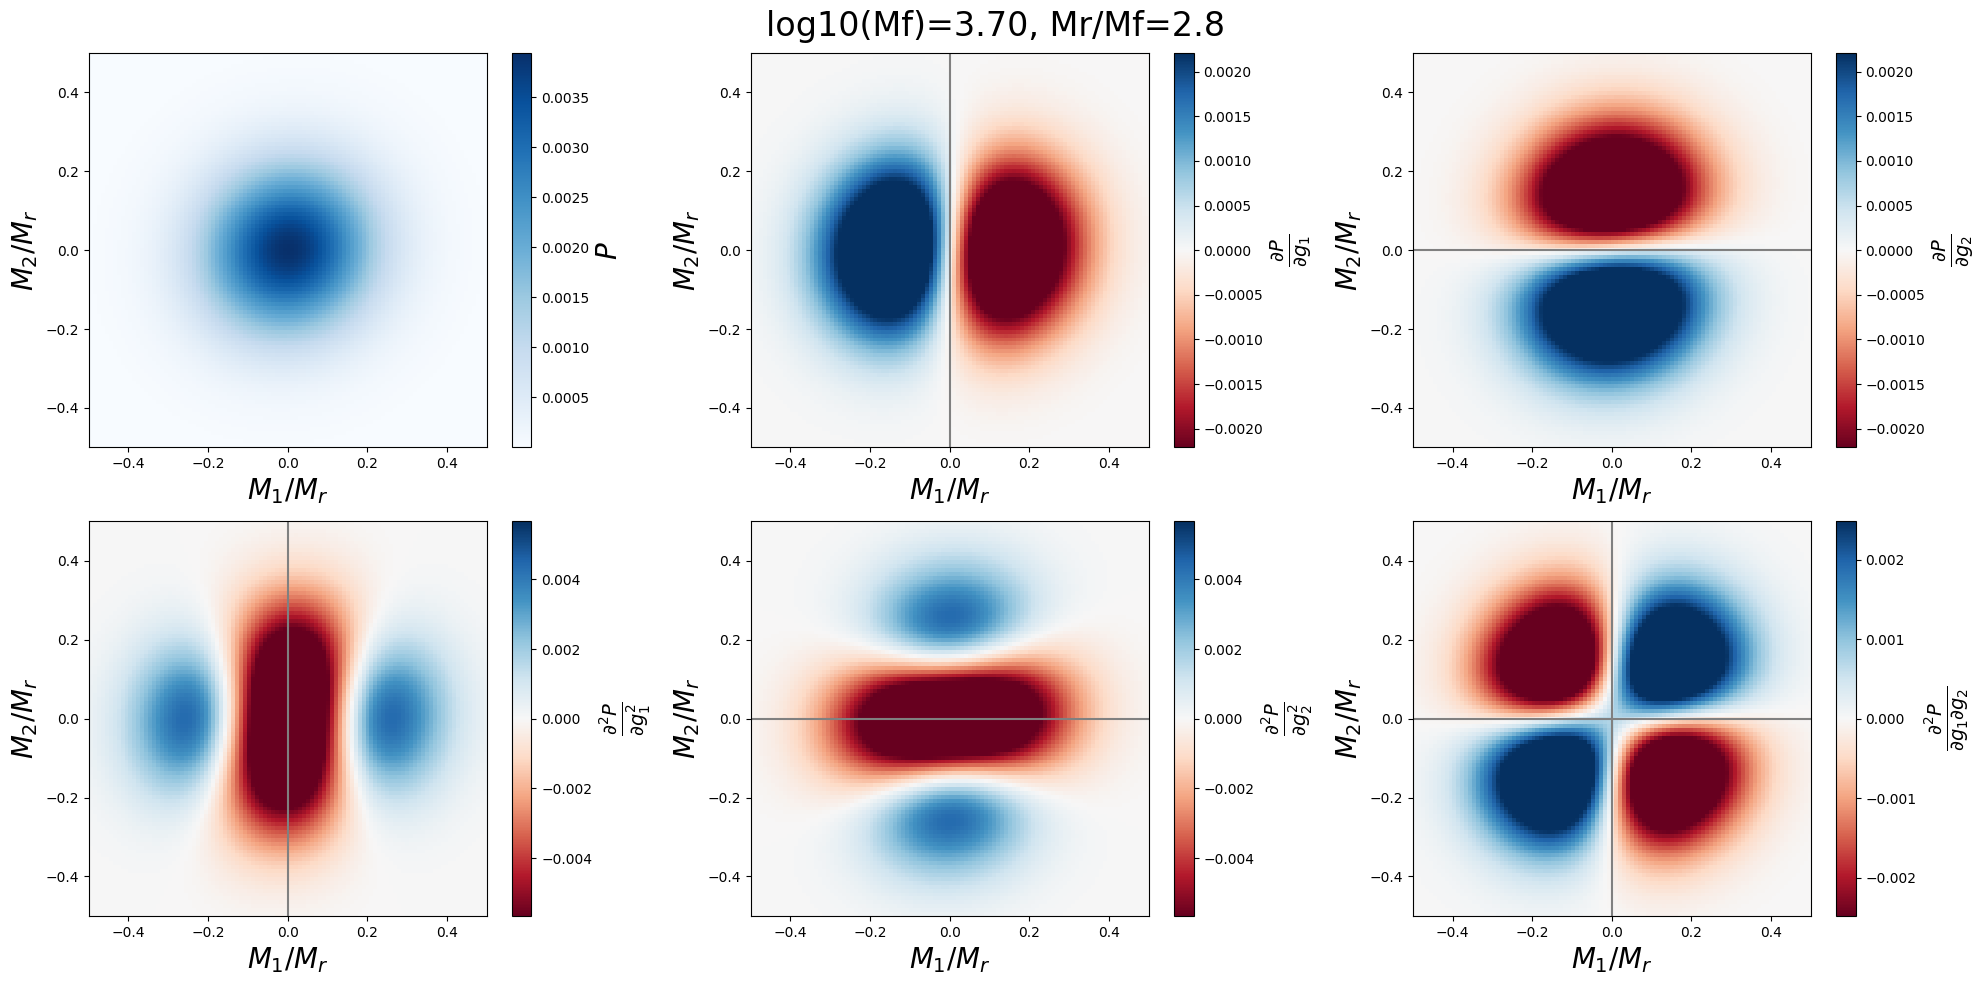

In [ ]:
log10mf_fix = np.log10(5000.0)
mrmf_fix = 2.8
n_g = 101
m1mr_vals = np.linspace(-0.5, 0.5, n_g)
m2mr_vals = np.linspace(-0.5, 0.5, n_g)

# Grid: outer loop = m1mr, inner loop = m2mr
# → reshape to (1, 1, n_g, n_g) for plot_prob_derivs_m1mr_m2mr
log_pts = jnp.array([
    [log10mf_fix, mrmf_fix, m1, m2]
    for m1 in m1mr_vals
    for m2 in m2mr_vals
])
std_pts = (log_pts - data_mean) / data_std

log_p, dlp_g1, dlp_g2, d2lp_g11, d2lp_g22, d2lp_g12 = flow_prob_and_derivs(std_pts)
p = jnp.exp(log_p)

def _to_grid(arr):
    return np.array(arr).reshape(1, 1, n_g, n_g)

plot_prob_derivs_m1mr_m2mr(
    m1mr_vals,
    m2mr_vals,
    _to_grid(p),
    _to_grid(p * dlp_g1),
    _to_grid(p * dlp_g2),
    _to_grid(p * (dlp_g1**2 + d2lp_g11)),
    _to_grid(p * (dlp_g2**2 + d2lp_g22)),
    _to_grid(p * (dlp_g1 * dlp_g2 + d2lp_g12)),
    title=f"log10(Mf)={log10mf_fix:.2f}, Mr/Mf={mrmf_fix:.1f}",
)

## Cell 10 — Prob Derivatives Grid: log10(Mf) vs Mr/Mf

Evaluates P and its shear derivatives on a 2D grid in (log10 Mf, Mr/Mf) space
at fixed M1/Mr = M2/Mr = 0.

**Axis order note:** `plot_prob_derivs_log10mf_mrmf` calls `np.sum(probs, axis=(2,3))`
and passes the result to `imshow` with `extent=(log10mf_min, log10mf_max, mrmf_min, mrmf_max)`.
For the array axes to match (rows=mrmf, cols=log10mf), the outer loop must iterate over mrmf.

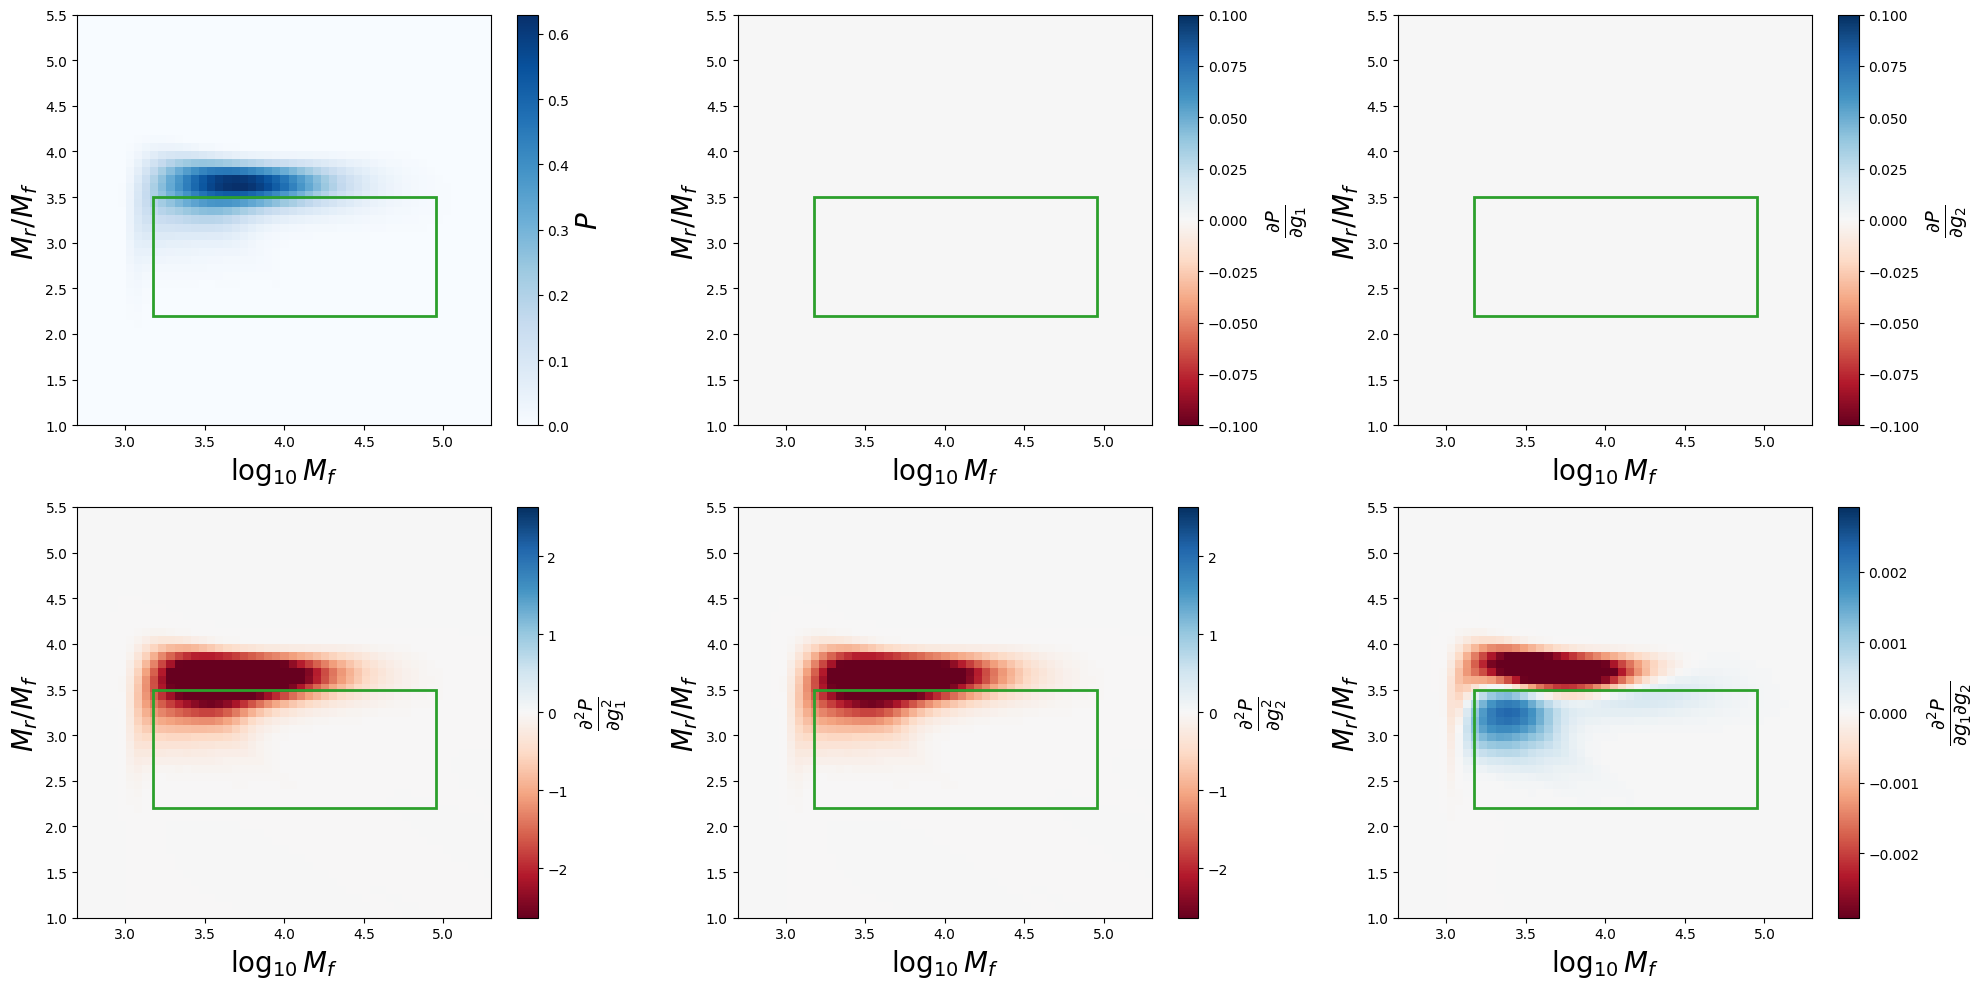

In [10]:
n_lf, n_mr = 51, 51
log10mf_vals = np.linspace(np.log10(500), np.log10(200000), n_lf)
mrmf_vals    = np.linspace(1.0, 5.5, n_mr)

# Grid: outer loop = mrmf, inner loop = log10mf
# → reshape to (n_mr, n_lf, 1, 1) so sum over (2,3) gives (n_mr, n_lf)
log_pts2 = jnp.array([
    [lf, mr, 0.0, 0.0]
    for mr in mrmf_vals
    for lf in log10mf_vals
])
std_pts2 = (log_pts2 - data_mean) / data_std

log_p2, dlp_g1, dlp_g2, d2lp_g11, d2lp_g22, d2lp_g12 = flow_prob_and_derivs(std_pts2)
p2 = jnp.exp(log_p2)

def _to_grid2(arr):
    return np.array(arr).reshape(n_mr, n_lf, 1, 1)

plot_prob_derivs_log10mf_mrmf(
    log10mf_vals,
    mrmf_vals,
    _to_grid2(p2),
    _to_grid2(p2 * dlp_g1),
    _to_grid2(p2 * dlp_g2),
    _to_grid2(p2 * (dlp_g1**2 + d2lp_g11)),
    _to_grid2(p2 * (dlp_g2**2 + d2lp_g22)),
    _to_grid2(p2 * (dlp_g1 * dlp_g2 + d2lp_g12)),
)

## Cell 11 — Single-Object RQMC PQR Sanity Check

Computes P, Q, R for a single "near" galaxy target to verify the inference pipeline.

In [12]:
x_near0 = jnp.array([2000.0, 3.3 * 2000.0, 0.1 * 3.3 * 2000.0, 0.0])
x_near, Sigma_near = transform_dataset_to_standard(raw2standard, x_near0[None], Sigma0[None])

CA_raw = make_augmentation_noise_raw_jax(
    Sigma0,
    current_snr=float(x_near0[0] / jnp.sqrt(Sigma0[0, 0])),
    target_snr=20.0,
)

key, subkey = jr.split(key)
result = rqmc_integrate_pqr_jax(
    log_flow_fn,
    flow_prob_and_derivs,
    x_near[0],
    Sigma_near[0],
    subkey,
    n_points=2**8,
    n_replicates=16,
    mu_raw=x_near0,
    CM_raw=Sigma0,
    CA_raw=CA_raw,
    std_scales=jnp.array(raw2standard.std),
)
P_est, P_se, Q1_est, Q1_se, Q2_est, Q2_se, R11_est, R11_se, R22_est, R22_se, R12_est, R12_se = result[:12]

print(f"P  = {P_est:.4e} ± {P_se:.2e}")
print(f"Q1 = {Q1_est:.4e} ± {Q1_se:.2e}")
print(f"Q2 = {Q2_est:.4e} ± {Q2_se:.2e}")
print(f"R11= {R11_est:.4e} ± {R11_se:.2e}")
print(f"R22= {R22_est:.4e} ± {R22_se:.2e}")
print(f"R12= {R12_est:.4e} ± {R12_se:.2e}")

P  = 2.0197e-32 ± 0.00e+00
Q1 = -2.5035e-32 ± 0.00e+00
Q2 = 7.2679e-34 ± 0.00e+00
R11= -1.6193e-32 ± 0.00e+00
R22= -4.2714e-32 ± 0.00e+00
R12= -3.1964e-33 ± 0.00e+00


## Cell 12 — Load Grid Data & Prepare Inputs

Loads the ±shear galaxy grid files, applies selection cuts, subsamples 100k objects,
and transforms to standardized moment coordinates.

In [13]:
import bfd

joined_grid = load_grid_data(GRID_P_PATH, GRID_M_PATH)
pqr_sim_p = bfd.stripMuPqr(joined_grid["pqr_p"])
pqr_sim_m = bfd.stripMuPqr(joined_grid["pqr_m"])

target_p_moments = jnp.array(joined_grid["moments_p"][:, :4])
target_m_moments = jnp.array(joined_grid["moments_m"][:, :4])

# Selection cuts
sel = (
    (target_p_moments[:, 0] > 1500)
    & (target_p_moments[:, 0] < 90000)
    & (target_p_moments[:, 1] / target_p_moments[:, 0] > 2.2)
    & (target_p_moments[:, 1] / target_p_moments[:, 0] < 3.5)
)
targets_p    = target_p_moments[sel]
targets_m    = target_m_moments[sel]
pqr_sim_p_sel = pqr_sim_p[sel]
pqr_sim_m_sel = pqr_sim_m[sel]

mask = (pqr_sim_p_sel[:, 0] >= 1e-10) & (pqr_sim_m_sel[:, 0] >= 1e-10)
targets_p     = targets_p[mask]
targets_m     = targets_m[mask]
pqr_sim_p_sel = pqr_sim_p_sel[mask]
pqr_sim_m_sel = pqr_sim_m_sel[mask]

N_targets = targets_p.shape[0]
key, subkey = jr.split(key)
idx = jr.choice(subkey, N_targets, shape=(100_000,), replace=False)
targets_p_10k = targets_p[idx]
targets_m_10k = targets_m[idx]

print(f"Grid objects after selection+mask: {N_targets}, subsampled: {idx.shape[0]}")

def _unpack_cov(packed_raw, boolean_sel, subsample_idx):
    """Unpack upper-triangular packed 5x5 covariance and extract 4x4 submatrix."""
    packed_sel = packed_raw[boolean_sel][subsample_idx]
    C = np.zeros((packed_sel.shape[0], 5, 5))
    j = 0
    for i in range(5):
        nv = 5 - i
        C[:, i, i:] = packed_sel[:, j: j + nv]
        C[:, i:, i] = packed_sel[:, j: j + nv]
        j += nv
    return C[:, :4, :4]

CM_raw_p = _unpack_cov(joined_grid["covariance_p"], sel, idx)
CM_raw_m = _unpack_cov(joined_grid["covariance_m"], sel, idx)

mu_std_p, sigma_std_p = transform_dataset_to_standard(raw2standard, targets_p_10k, CM_raw_p)
mu_std_m, sigma_std_m = transform_dataset_to_standard(raw2standard, targets_m_10k, CM_raw_m)

Grid objects after selection+mask: 1251877, subsampled: 100000


## Cell 13 — Run RQMC PQR on Grid (±shear)

This is the main computational step — may take several minutes.

In [ ]:
print("Running flow-based RQMC PQR on grid (+shear)...")
(
    P_p, P_se_p, Q1_p, Q1_se_p, Q2_p, Q2_se_p,
    R11_p, R11_se_p, R22_p, R22_se_p, R12_p, R12_se_p,
) = rqmc_pqr_grid(
    mu_std_p,
    sigma_std_p,
    targets_p_10k,
    CM_raw_p,
    n_points=2**10,
    n_replicates=16,
    batch_size=512,
    raw2standard=raw2standard,
    flow_prob_and_derivs=flow_prob_and_derivs,
    log_flow_fn=log_flow_fn,
)

print("Running flow-based RQMC PQR on grid (-shear)...")
(
    P_m, P_se_m, Q1_m, Q1_se_m, Q2_m, Q2_se_m,
    R11_m, R11_se_m, R22_m, R22_se_m, R12_m, R12_se_m,
) = rqmc_pqr_grid(
    mu_std_m,
    sigma_std_m,
    targets_m_10k,
    CM_raw_m,
    n_points=2**10,
    n_replicates=16,
    batch_size=512,
    raw2standard=raw2standard,
    flow_prob_and_derivs=flow_prob_and_derivs,
    log_flow_fn=log_flow_fn,
)
print("Done.")

Running flow-based RQMC PQR on grid (+shear)...
Invalid nan value encountered in the output of a jax.jit function. Calling the de-optimized version.


E0330 15:01:15.228516   92082 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


## Cell 14 — Assemble PQR & Per-Object g Estimates

In [ ]:
pqr_arr_p, pqr_arr_m = assemble_pqr_from_flow(
    P_p, Q1_p, Q2_p, R11_p, R22_p, R12_p,
    P_m, Q1_m, Q2_m, R11_m, R22_m, R12_m,
)

def _pqr_to_Q_R_g(P, Q1, Q2, R11, R22, R12):
    """Convert scalar PQR arrays to normalized Q vectors, R matrices, and g estimates."""
    Q = jnp.stack([Q1, Q2], axis=-1)
    R = jnp.stack(
        [jnp.stack([R11, R12], axis=-1), jnp.stack([R12, R22], axis=-1)],
        axis=-2,
    )
    Q_tot = Q / P[:, None]
    R_tot = (
        jnp.einsum("...i,...j->...ij", Q, Q) / P[:, None, None] ** 2
        - R / P[:, None, None]
    )
    g_est = jnp.einsum("...ij,...j->...i", jnp.linalg.inv(R_tot), Q_tot)
    return Q_tot, R_tot, g_est

Q_tot_p, R_tot_p, g_est_p = _pqr_to_Q_R_g(P_p, Q1_p, Q2_p, R11_p, R22_p, R12_p)
Q_tot_m, R_tot_m, g_est_m = _pqr_to_Q_R_g(P_m, Q1_m, Q2_m, R11_m, R22_m, R12_m)

print(f"g (flow, +shear): {pqr2g(pqr_arr_p)}")
print(f"g (flow, -shear): {pqr2g(pqr_arr_m)}")

pqr_arr = jnp.concatenate([pqr_arr_p, pqr_arr_m], axis=-1)
print(f"Multiplicative bias (point): {pqr2multbias(pqr_arr):.4f}")

g (flow, +shear): [0.02239839 0.00414767]
g (flow, -shear): [-0.03094715  0.00505351]
Multiplicative bias (point): 0.3336


## Cell 15 — Plot: g Comparison (Flow vs Templates)

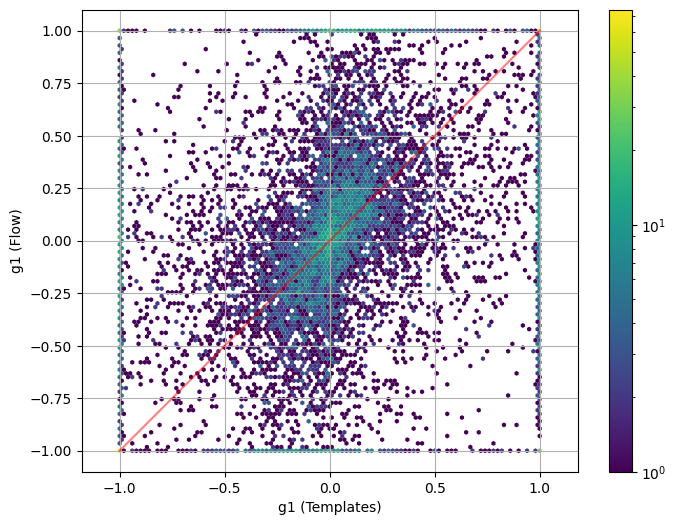

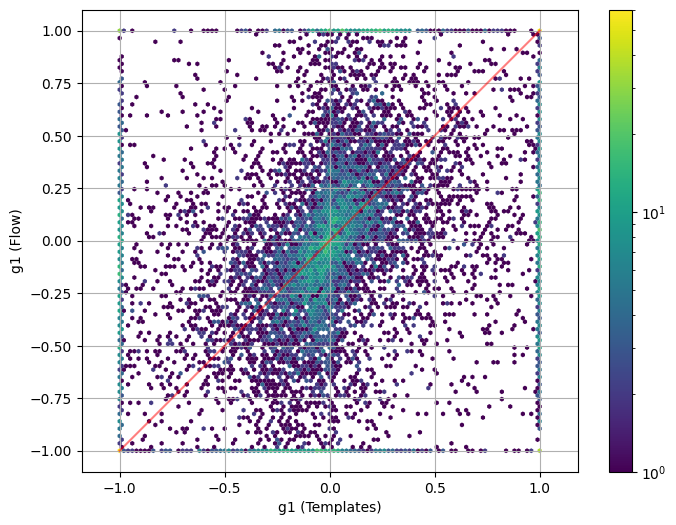

In [ ]:
def _tmpl_pqr_to_g(pqr):
    """Compute per-object g estimates from template-based PQR arrays."""
    P   = pqr[:, 0]
    Q1  = pqr[:, 1]
    Q2  = pqr[:, 2]
    R11 = pqr[:, 3]
    R22 = pqr[:, 4]
    R12 = pqr[:, 5]
    _, _, g = _pqr_to_Q_R_g(P, Q1, Q2, R11, R22, R12)
    return g

g_est_p_tmpl = _tmpl_pqr_to_g(pqr_sim_p_sel[idx])
g_est_m_tmpl = _tmpl_pqr_to_g(pqr_sim_m_sel[idx])

plot_g_comparison(g_est_p, g_est_p_tmpl, g_est_m, g_est_m_tmpl)

## Cell 16 — Plots: Q and R Distributions

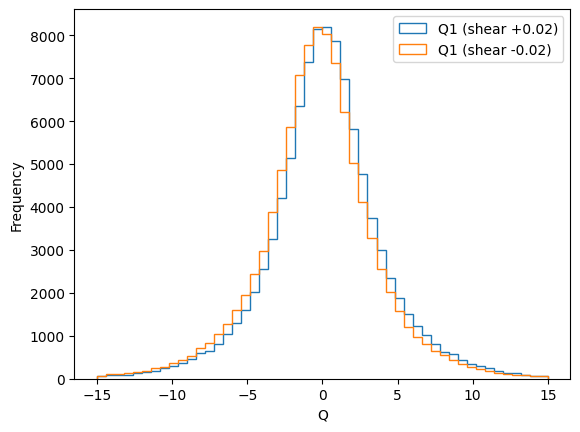

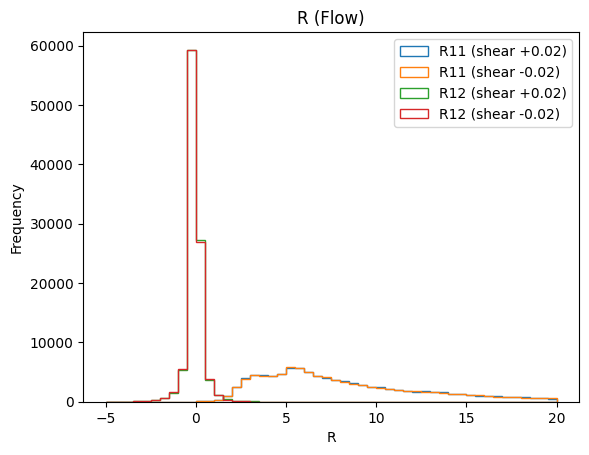

In [ ]:
plot_Q_distributions(Q_tot_p, Q_tot_m)
plot_R_distributions(R_tot_p, R_tot_m)

## Cell 17 — Plot: g Distributions

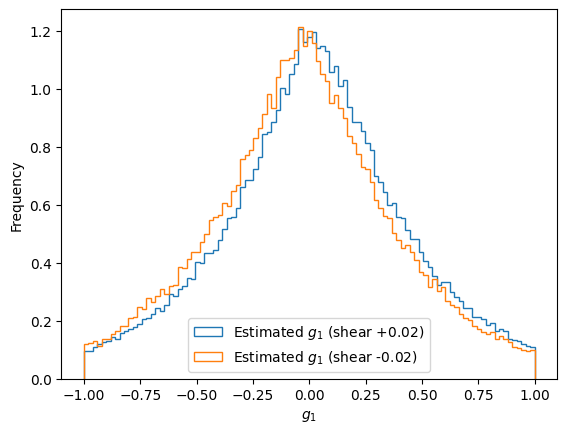

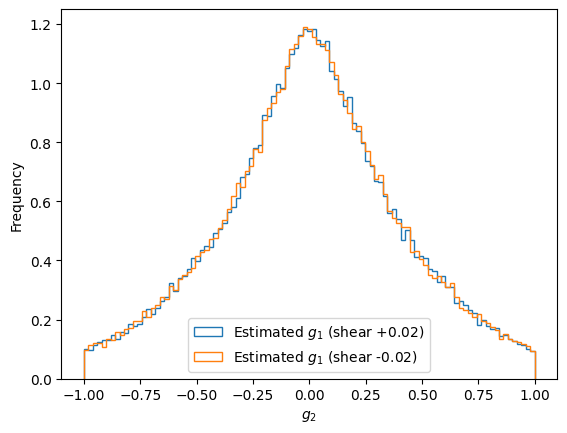

In [ ]:
plot_g_distributions(g_est_p, g_est_m)

## Cell 18 — Bootstrap Multiplicative Bias

In [ ]:
stats = bootstrap_total_mult_bias(
    pqr_arr_p,
    pqr_arr_m,
    n_boot=2000,
    delta_g=0.04,
    key=jr.PRNGKey(42),
)
print(f"m (point):        {float(stats['m_point']):+.4f}")
print(f"m (bootstrap mean ± 1σ): {float(stats['m_mean']):+.4f} ± {float(stats['m_std']):.4f}")
print(f"m (16–84%):       [{float(stats['m_p16']):+.4f}, {float(stats['m_p84']):+.4f}]")
print(f"N objects used:   {stats['n_used']}")

m (point):        +0.3336
m (bootstrap mean ± 1σ): +0.3594 ± 0.0480
m (16–84%):       [+0.3128, +0.4068]
N objects used:   100000


## Cell 19 — Plot: Multiplicative Bias Hexbin

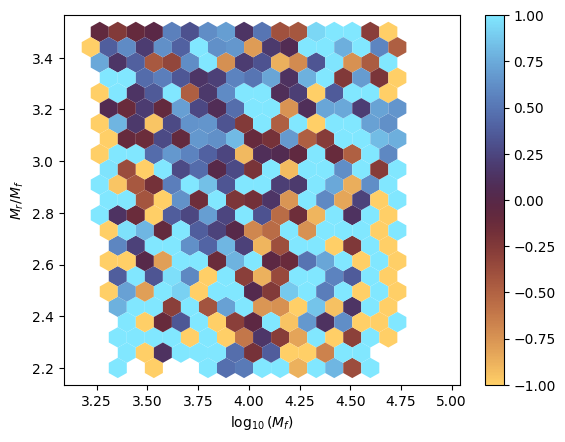

In [ ]:
plot_mult_bias_hexbin(targets_p_10k, pqr_arr, pqr2multbias)